<a href="https://colab.research.google.com/github/pillisirichandana21/employee-attrition-analysis/blob/main/EDA_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bank Marketing Campaign Analysis

## 1. Project Overview

This project performs Exploratory Data Analysis (EDA) on the UCI Bank Marketing
Dataset.

The objective is to understand customer characteristics, marketing campaign
performance and factors associated with customers subscribing to a term deposit.

## Problem Statement

A bank conducts marketing campaigns to promote term deposits.

The objective of this analysis is to understand customer behaviour and identify
patterns associated with campaign success.

## Key Questions

1. What percentage of customers subscribed?
2. Which age groups are more likely to subscribe?
3. Does job type influence subscription?
4. Does education level influence response?
5. Does marital status relate to subscription?
6. Does account balance differ between subscribed and non-subscribed customers?
7. How does campaign contact frequency affect the outcome?
8. Which communication method appears most effective?
9. Does previous campaign history relate to the current outcome?
10. Which customer segments show interesting patterns?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


In [11]:
import zipfile
import os

zip_path = "/content/bank+marketing.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/bank_marketing")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [12]:
import os

for root, dirs, files in os.walk("/content/bank_marketing"):
    for file in files:
        print(os.path.join(root, file))

/content/bank_marketing/bank-additional.zip
/content/bank_marketing/bank.zip


In [14]:
import zipfile

zip_path = "/content/bank_marketing/bank.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/bank_data")

print("Bank dataset extracted successfully!")

Bank dataset extracted successfully!


In [15]:
import os

for root, dirs, files in os.walk("/content/bank_data"):
    for file in files:
        print(os.path.join(root, file))

/content/bank_data/bank-full.csv
/content/bank_data/bank.csv
/content/bank_data/bank-names.txt


In [16]:
import pandas as pd
import os

# Find CSV files
csv_files = []

for root, dirs, files in os.walk("/content/bank_data"):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for f in csv_files:
    print(f)

CSV files found:
/content/bank_data/bank-full.csv
/content/bank_data/bank.csv


In [17]:
df = pd.read_csv("/content/bank_data/bank-full.csv", sep=";")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

Dataset loaded successfully!
Rows and columns: (45211, 17)


In [18]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [19]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [21]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [22]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [23]:
missing_values = df.isnull().sum()

missing_values

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [24]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(
    ascending=False
)

,0
age,0.0
job,0.0
marital,0.0
education,0.0
default,0.0
balance,0.0
housing,0.0
loan,0.0
contact,0.0
day,0.0


In [25]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df)
    ) * 100
})

missing_table.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


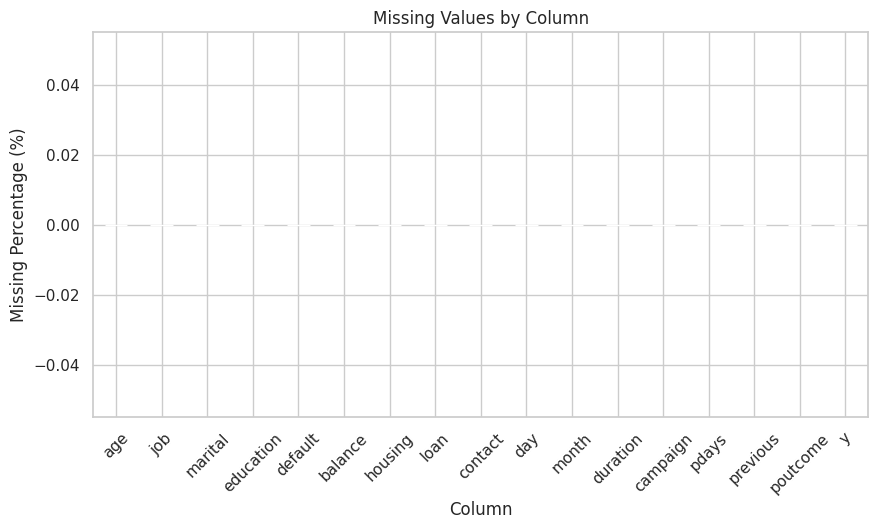

In [26]:
plt.figure(figsize=(10, 5))

missing_table["Missing Percentage"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45)

plt.show()

In [27]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [28]:
df[df.duplicated()].head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


In [30]:
df = df.drop_duplicates().copy()

In [31]:
print(
    "Duplicates after cleaning:",
    df.duplicated().sum()
)

Duplicates after cleaning: 0


In [32]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [33]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [34]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

numerical_columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [35]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

 marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

 education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

 default
default
no     44396
yes      815
Name: count, dtype: int64

 housing
housing
yes    25130
no     20081
Name: count, dtype: int64

 loan
loan
no     37967
yes     7244
Name: count, dtype: int64

 contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

 month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

In [37]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


In [38]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


In [39]:
subscription_percentage = (
    df["y"].value_counts(normalize=True)
    * 100
)

subscription_percentage

,proportion
y,
no,88.30152
yes,11.69848


In [40]:
yes_percentage = (
    df["y"].value_counts(normalize=True)
    .get("yes", 0)
    * 100
)

no_percentage = (
    df["y"].value_counts(normalize=True)
    .get("no", 0)
    * 100
)

print(
    f"Customers who subscribed: {yes_percentage:.2f}%"
)

print(
    f"Customers who did not subscribe: {no_percentage:.2f}%"
)

Customers who subscribed: 11.70%
Customers who did not subscribe: 88.30%


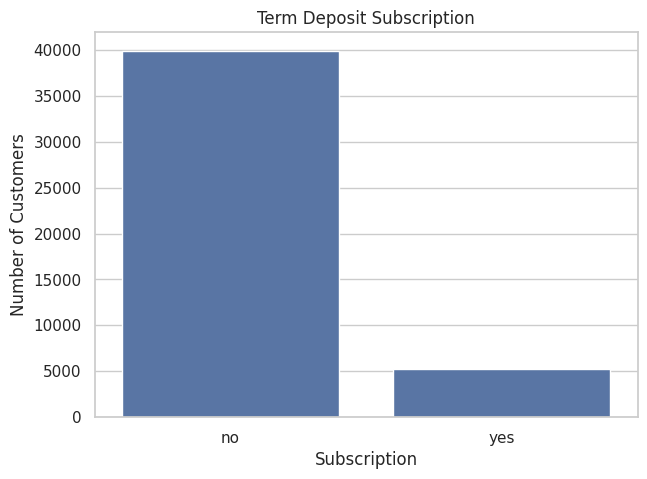

In [41]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="y"
)

plt.title("Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

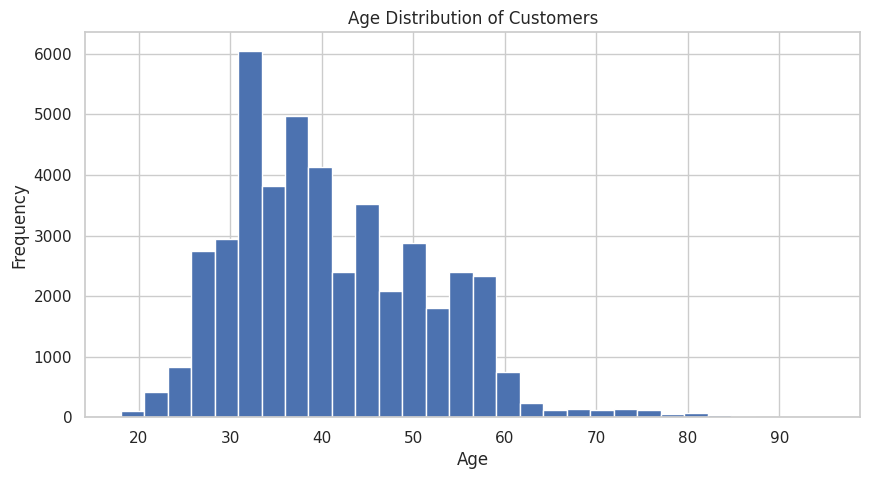

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["age"],
    bins=30
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

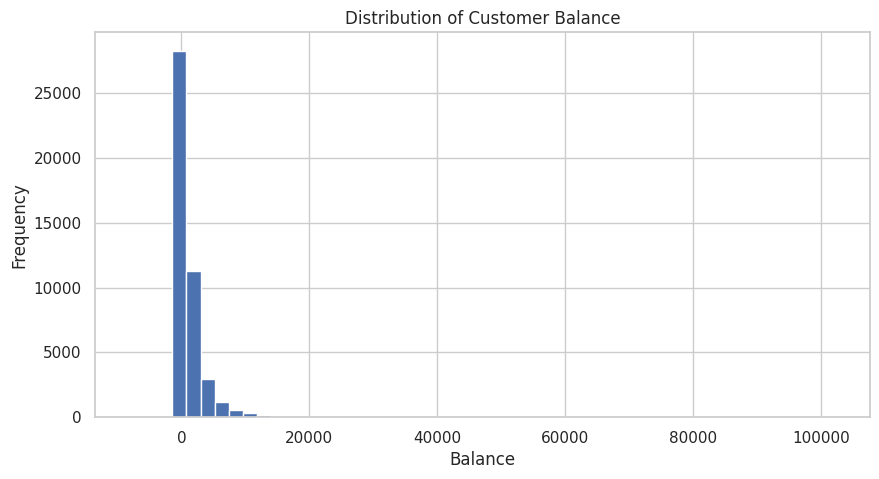

In [43]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["balance"],
    bins=50
)

plt.title("Distribution of Customer Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

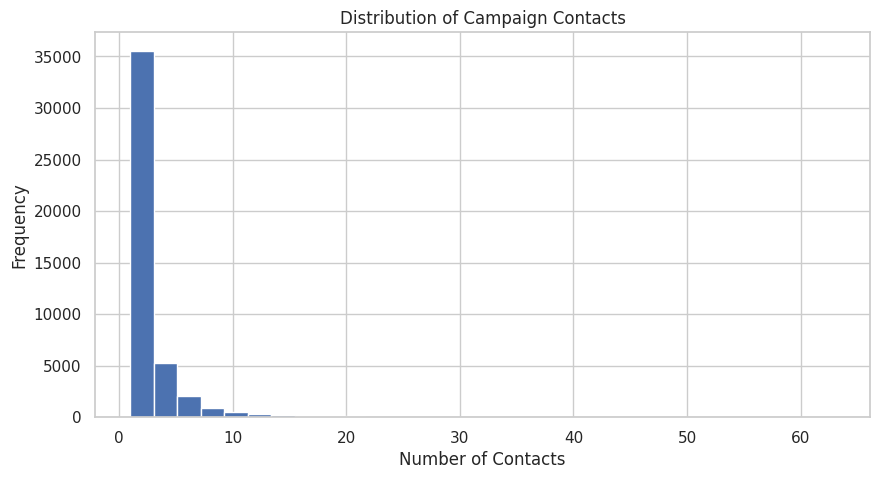

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["campaign"],
    bins=30
)

plt.title("Distribution of Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")

plt.show()

In [47]:
bins = [17, 25, 35, 45, 55, 65, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["AgeGroup"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [48]:
df["AgeGroup"].value_counts().sort_index()

,count
AgeGroup,
18-25,1336
26-35,15571
36-45,13856
46-55,9548
56-65,4149
65+,751


In [49]:
age_subscription = pd.crosstab(
    df["AgeGroup"],
    df["y"],
    normalize="index"
) * 100

age_subscription

y,no,yes
AgeGroup,,
18-25,76.047904,23.952096
26-35,87.996917,12.003083
36-45,90.610566,9.389434
46-55,90.647256,9.352744
56-65,85.876115,14.123885
65+,57.390146,42.609854


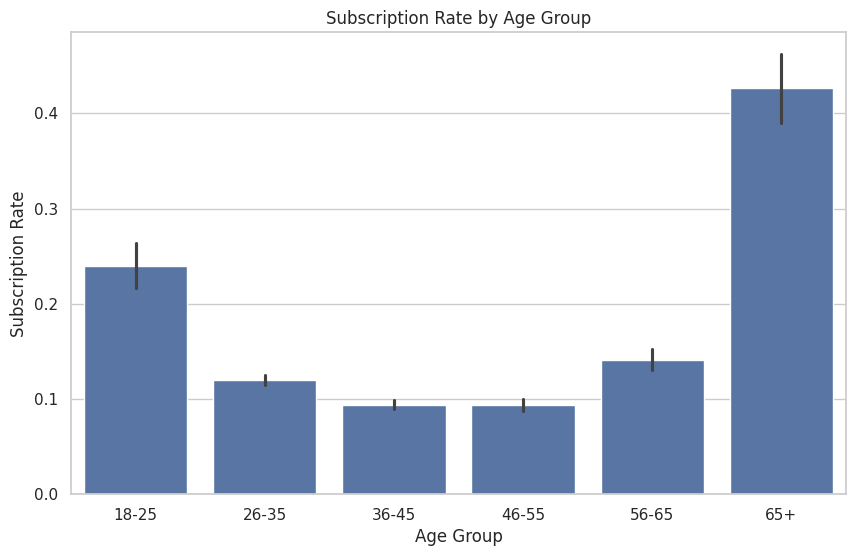

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="AgeGroup",
    y=df["y"].eq("yes").astype(int)
)

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate")

plt.show()

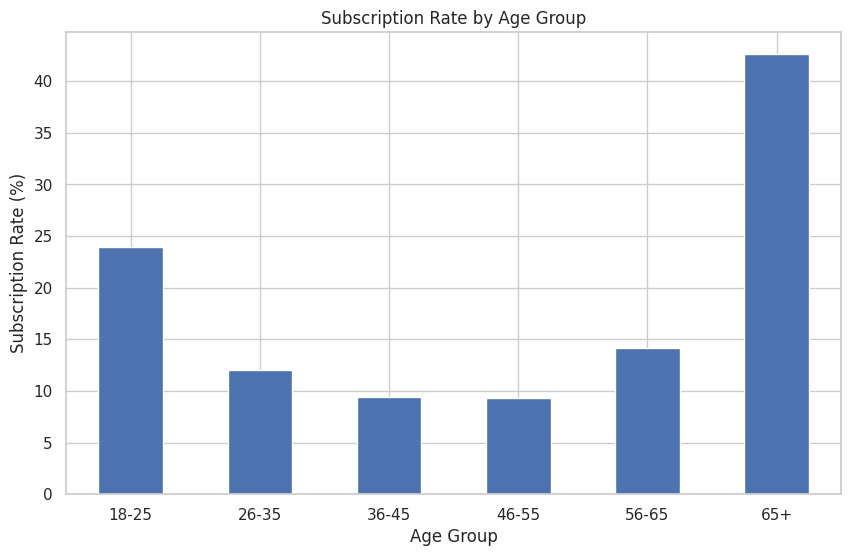

In [51]:
age_yes_rate = age_subscription["yes"]

plt.figure(figsize=(10, 6))

age_yes_rate.plot(kind="bar")

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [52]:
df["job"].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [53]:
job_subscription = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

job_subscription

y,no,yes
job,,
admin.,87.797331,12.202669
blue-collar,92.725031,7.274969
entrepreneur,91.728312,8.271688
housemaid,91.209677,8.790323
management,86.244449,13.755551
retired,77.208481,22.791519
self-employed,88.157061,11.842939
services,91.116996,8.883004
student,71.321962,28.678038


In [54]:
job_yes_rate = (
    job_subscription["yes"]
    .sort_values(ascending=False)
)

job_yes_rate

,yes
job,
student,28.678038
retired,22.791519
unemployed,15.502686
management,13.755551
admin.,12.202669
self-employed,11.842939
unknown,11.805556
technician,11.056996
services,8.883004


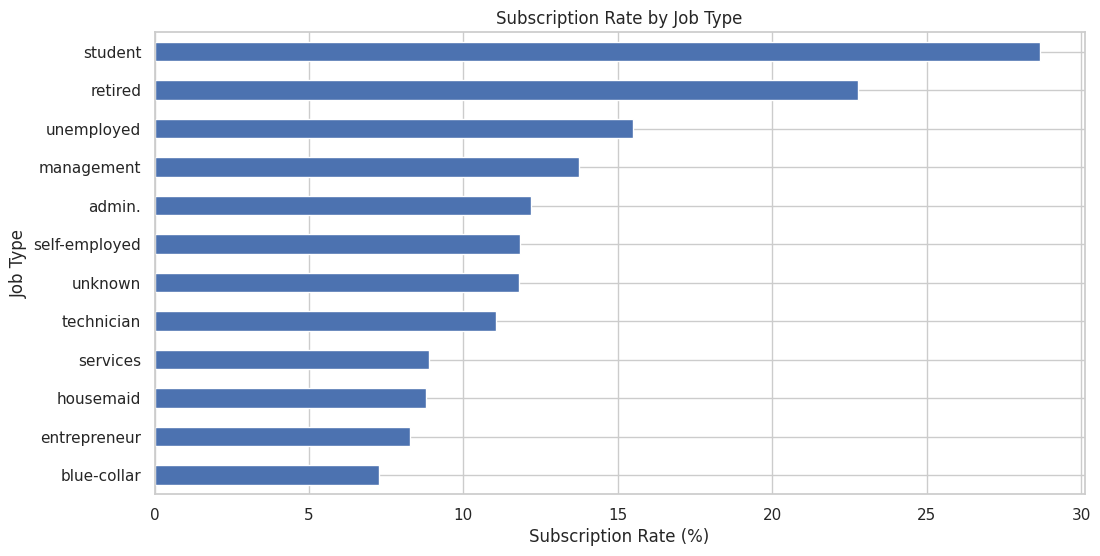

In [55]:
plt.figure(figsize=(12, 6))

job_yes_rate.sort_values().plot(
    kind="barh"
)

plt.title("Subscription Rate by Job Type")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job Type")

plt.show()

In [56]:
df["education"].value_counts()

,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


In [57]:
education_subscription = pd.crosstab(
    df["education"],
    df["y"],
    normalize="index"
) * 100

education_subscription

y,no,yes
education,,
primary,91.373522,8.626478
secondary,89.440565,10.559435
tertiary,84.993610,15.006390
unknown,86.429725,13.570275


In [58]:
education_yes_rate = (
    education_subscription["yes"]
    .sort_values(ascending=False)
)

education_yes_rate

,yes
education,
tertiary,15.006390
unknown,13.570275
secondary,10.559435
primary,8.626478


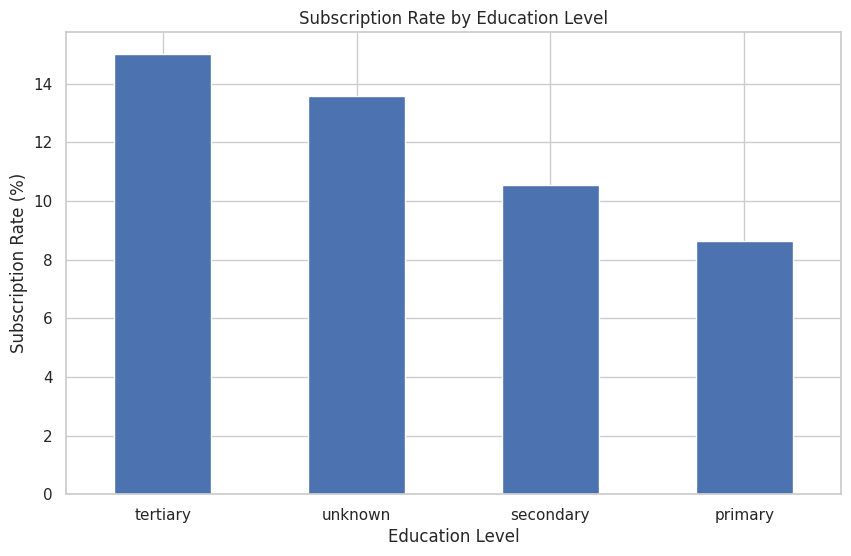

In [59]:
plt.figure(figsize=(10, 6))

education_yes_rate.plot(
    kind="bar"
)

plt.title("Subscription Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [60]:
df["marital"].value_counts()

,count
marital,
married,27214
single,12790
divorced,5207


In [61]:
marital_subscription = pd.crosstab(
    df["marital"],
    df["y"],
    normalize="index"
) * 100

marital_subscription

y,no,yes
marital,,
divorced,88.054542,11.945458
married,89.876534,10.123466
single,85.050821,14.949179


In [62]:
marital_yes_rate = (
    marital_subscription["yes"]
)

marital_yes_rate

,yes
marital,
divorced,11.945458
married,10.123466
single,14.949179


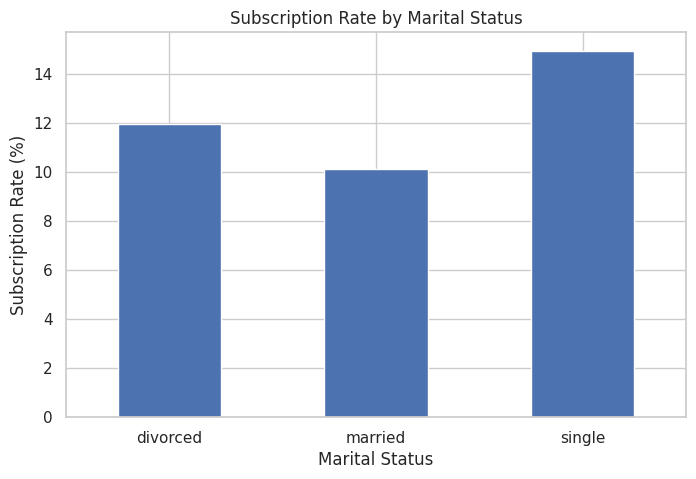

In [63]:
plt.figure(figsize=(8, 5))

marital_yes_rate.plot(
    kind="bar"
)

plt.title("Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [64]:
balance_by_subscription = (
    df.groupby("y")["balance"]
    .agg(["mean", "median", "min", "max"])
)

balance_by_subscription

,mean,median,min,max
y,,,,
no,1303.714969,417.0,-8019,102127
yes,1804.267915,733.0,-3058,81204


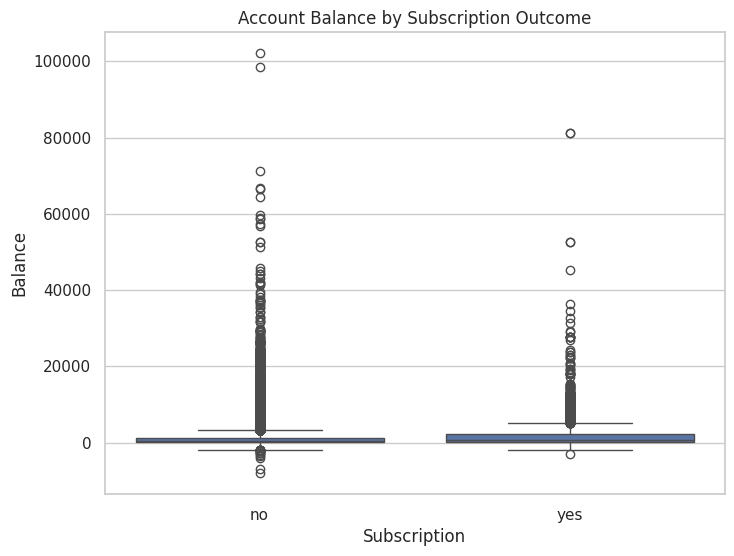

In [65]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="y",
    y="balance"
)

plt.title(
    "Account Balance by Subscription Outcome"
)

plt.xlabel("Subscription")
plt.ylabel("Balance")

plt.show()

In [66]:
df["campaign"].describe()

,campaign
count,45211.000000
mean,2.763841
std,3.098021
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,63.000000


In [67]:
campaign_subscription = pd.crosstab(
    df["campaign"],
    df["y"],
    normalize="index"
) * 100

campaign_subscription.head(20)

y,no,yes
campaign,,
1,85.402417,14.597583
2,88.796481,11.203519
3,88.806376,11.193624
4,90.999432,9.000568
5,92.120181,7.879819
6,92.873741,7.126259
7,93.605442,6.394558
8,94.074074,5.925926
9,93.577982,6.422018


In [68]:
campaign_yes_rate = (
    campaign_subscription["yes"]
)

campaign_yes_rate.head(20)

,yes
campaign,
1,14.597583
2,11.203519
3,11.193624
4,9.000568
5,7.879819
6,7.126259
7,6.394558
8,5.925926
9,6.422018


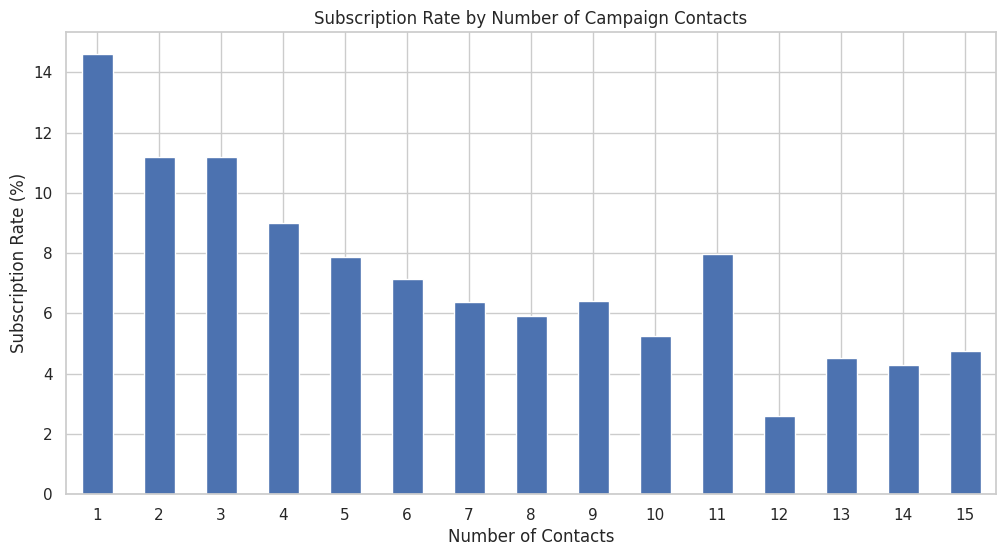

In [69]:
campaign_plot_data = (
    campaign_yes_rate
    .head(15)
)

plt.figure(figsize=(12, 6))

campaign_plot_data.plot(
    kind="bar"
)

plt.title(
    "Subscription Rate by Number of Campaign Contacts"
)

plt.xlabel("Number of Contacts")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [70]:
df["contact"].value_counts()

,count
contact,
cellular,29285
unknown,13020
telephone,2906


In [71]:
contact_subscription = pd.crosstab(
    df["contact"],
    df["y"],
    normalize="index"
) * 100

contact_subscription

y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


In [72]:
contact_yes_rate = (
    contact_subscription["yes"]
    .sort_values(ascending=False)
)

contact_yes_rate

,yes
contact,
cellular,14.918900
telephone,13.420509
unknown,4.070661


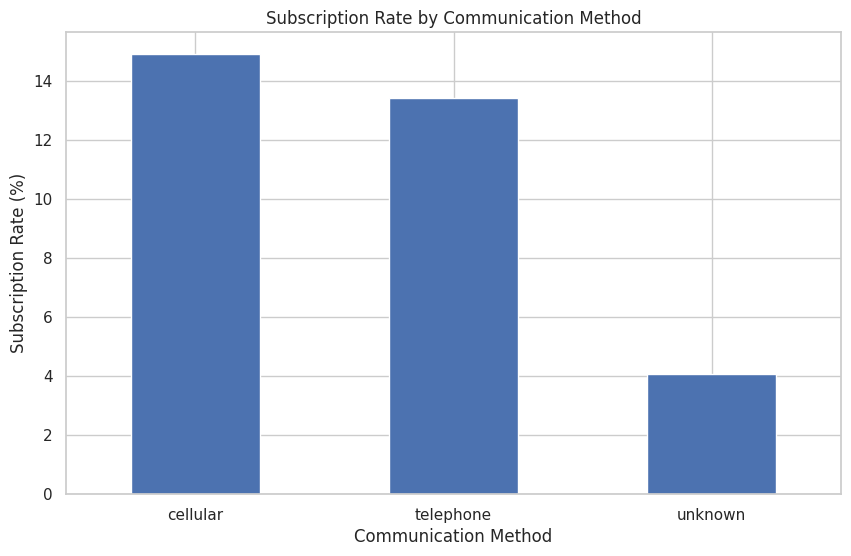

In [73]:
plt.figure(figsize=(10, 6))

contact_yes_rate.plot(
    kind="bar"
)

plt.title(
    "Subscription Rate by Communication Method"
)

plt.xlabel("Communication Method")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [74]:
df["poutcome"].value_counts()

,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


In [75]:
previous_outcome_subscription = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
) * 100

previous_outcome_subscription

y,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


In [76]:
previous_yes_rate = (
    previous_outcome_subscription["yes"]
)

previous_yes_rate

,yes
poutcome,
failure,12.609671
other,16.684783
success,64.725347
unknown,9.161503


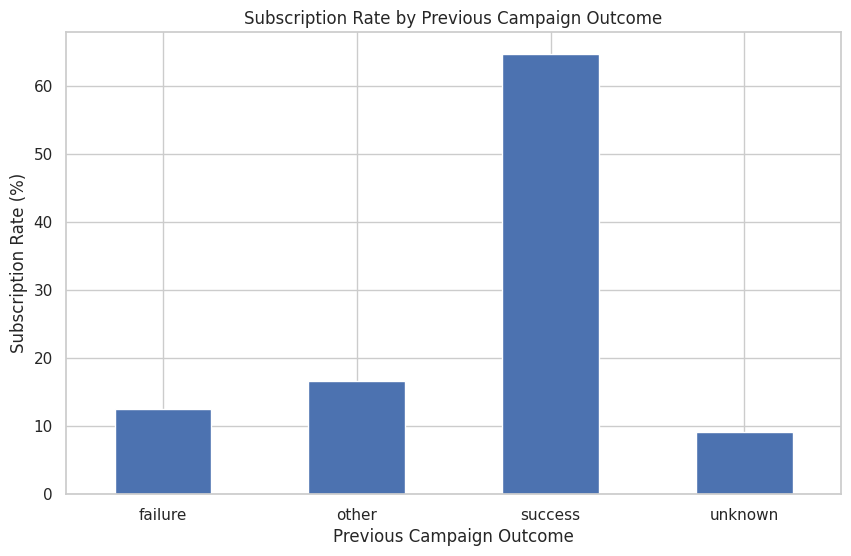

In [77]:
plt.figure(figsize=(10, 6))

previous_yes_rate.plot(
    kind="bar"
)

plt.title(
    "Subscription Rate by Previous Campaign Outcome"
)

plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [78]:
df["previous"].describe()

,previous
count,45211.000000
mean,0.580323
std,2.303441
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,275.000000


In [79]:
previous_subscription = pd.crosstab(
    df["previous"],
    df["y"],
    normalize="index"
) * 100

previous_subscription.head(20)

y,no,yes
previous,,
0,90.842669,9.157331
1,78.968254,21.031746
2,78.347578,21.652422
3,74.255692,25.744308
4,76.050420,23.949580
5,73.638344,26.361656
6,70.036101,29.963899
7,73.658537,26.341463
8,69.767442,30.232558


In [80]:
segment_analysis = pd.crosstab(
    [df["AgeGroup"], df["job"]],
    df["y"],
    normalize="index"
) * 100

segment_analysis

y                               no        yes
AgeGroup job                                 
18-25    admin.          82.911392  17.088608
         blue-collar     84.528302  15.471698
         entrepreneur    78.571429  21.428571
         housemaid       71.428571  28.571429
         management      72.477064  27.522936
         retired        100.000000   0.000000
         self-employed   68.000000  32.000000
         services        83.850932  16.149068
         student         63.902439  36.097561
         technician      80.891720  19.108280
         unemployed      80.769231  19.230769
         unknown        100.000000   0.000000
26-35    admin.          87.424547  12.575453
         blue-collar     91.669210   8.330790
         entrepreneur    92.987013   7.012987
         housemaid       91.981132   8.018868
         management      84.685196  15.314804
         retired         90.000000  10.000000
         self-employed   83.633094  16.366906
         services        90.785405   9.214595
         student         77.615063  22.384937
         technician      88.950637  11.049363
         unemployed      83.571429  16.428571
         unknown         83.720930  16.279070
36-45    admin.          89.515635  10.484365
         blue-collar     93.858872   6.141128
         entrepreneur    91.107078   8.892922
         housemaid       94.617564   5.382436
         management      88.149619  11.850381
         retired         97.014925   2.985075
         self-employed   91.412214   8.587786
         services        91.460674   8.539326
         student         72.340426  27.659574
         technician      89.626896  10.373104
         unemployed      85.813953  14.186047
         unknown         88.732394  11.267606
46-55    admin.          88.257576  11.742424
         blue-collar     93.567251   6.432749
         entrepreneur    92.039801   7.960199
         housemaid       90.379747   9.620253
         management      88.565697  11.434303
         retired         91.735537   8.264463
         self-employed   94.555874   5.444126
         services        92.535545   7.464455
         student         66.666667  33.333333
         technician      89.684625  10.315375
         unemployed      84.459459  15.540541
         unknown         88.118812  11.881188
56-65    admin.          82.674772  17.325228
         blue-collar     92.508711   7.491289
         entrepreneur    91.603053   8.396947
         housemaid       91.020408   8.979592
         management      82.772021  17.227979
         retired         83.066554  16.933446
         self-employed   83.760684  16.239316
         services        91.326531   8.673469
         technician      86.029412  13.970588
         unemployed      83.846154  16.153846
         unknown         91.666667   8.333333
65+      admin.          77.777778  22.222222
         blue-collar    100.000000   0.000000
         entrepreneur    75.000000  25.000000
         housemaid       60.714286  39.285714
         management      66.666667  33.333333
         retired         55.590551  44.409449
         self-employed   37.500000  62.500000
         services       100.000000   0.000000
         technician      58.333333  41.666667
         unemployed     100.000000   0.000000
         unknown         81.818182  18.181818

In [81]:
segment_yes_rate = (
    segment_analysis["yes"]
    .sort_values(ascending=False)
)

segment_yes_rate.head(15)

AgeGroup  job          
65+       self-employed    62.500000
          retired          44.409449
          technician       41.666667
          housemaid        39.285714
18-25     student          36.097561
46-55     student          33.333333
65+       management       33.333333
18-25     self-employed    32.000000
          housemaid        28.571429
36-45     student          27.659574
18-25     management       27.522936
65+       entrepreneur     25.000000
26-35     student          22.384937
65+       admin.           22.222222
18-25     entrepreneur     21.428571
Name: yes, dtype: float64

In [82]:
education_marital = pd.crosstab(
    [df["education"], df["marital"]],
    df["y"],
    normalize="index"
) * 100

education_marital

y                          no        yes
education marital                       
primary   divorced  86.170213  13.829787
          married   92.451392   7.548608
          single    89.331770  10.668230
secondary divorced  89.662522  10.337478
          married   90.530138   9.469862
          single    87.078737  12.921263
tertiary  divorced  86.199864  13.800136
          married   87.027565  12.972435
          single    81.636060  18.363940
unknown   divorced  85.798817  14.201183
          married   87.758621  12.241379
          single    83.712121  16.287879

In [83]:
education_marital_yes = (
    education_marital["yes"]
    .sort_values(ascending=False)
)

education_marital_yes.head(15)

education  marital 
tertiary   single      18.363940
unknown    single      16.287879
           divorced    14.201183
primary    divorced    13.829787
tertiary   divorced    13.800136
           married     12.972435
secondary  single      12.921263
unknown    married     12.241379
primary    single      10.668230
secondary  divorced    10.337478
           married      9.469862
primary    married      7.548608
Name: yes, dtype: float64

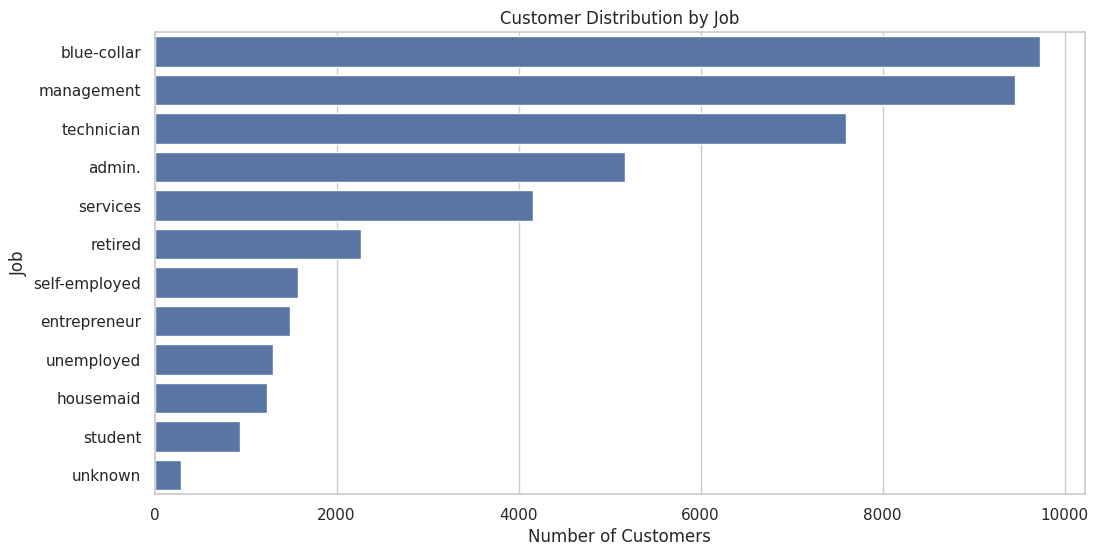

In [84]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

plt.title("Customer Distribution by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.show()

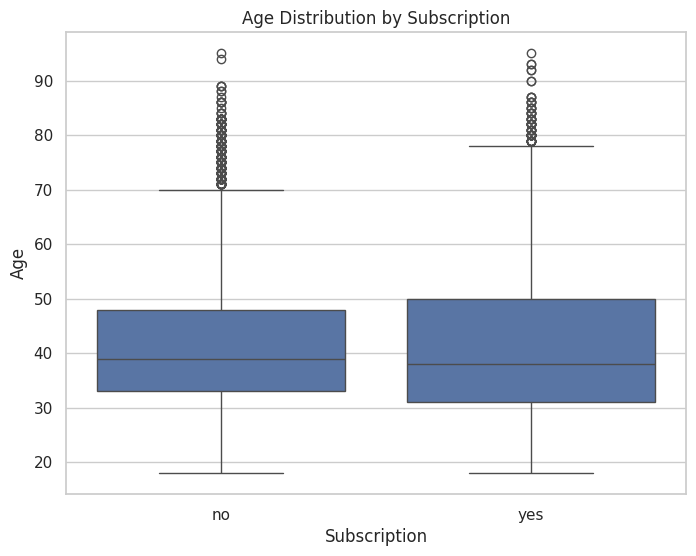

In [85]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="y",
    y="age"
)

plt.title("Age Distribution by Subscription")
plt.xlabel("Subscription")
plt.ylabel("Age")

plt.show()

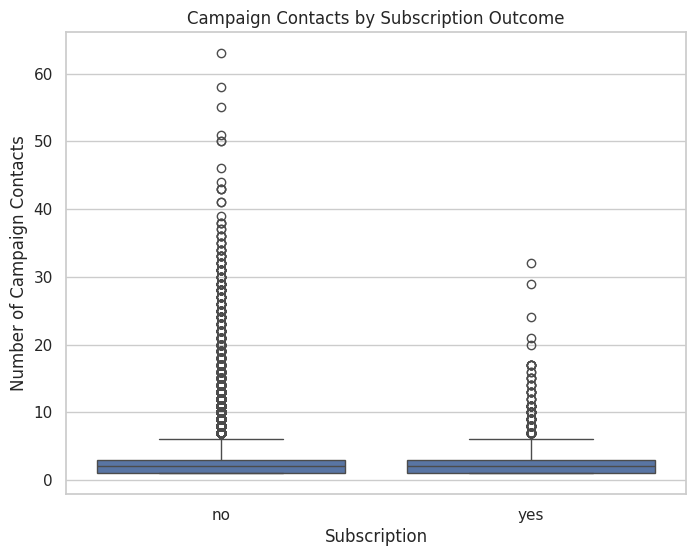

In [86]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="y",
    y="campaign"
)

plt.title(
    "Campaign Contacts by Subscription Outcome"
)

plt.xlabel("Subscription")
plt.ylabel("Number of Campaign Contacts")

plt.show()

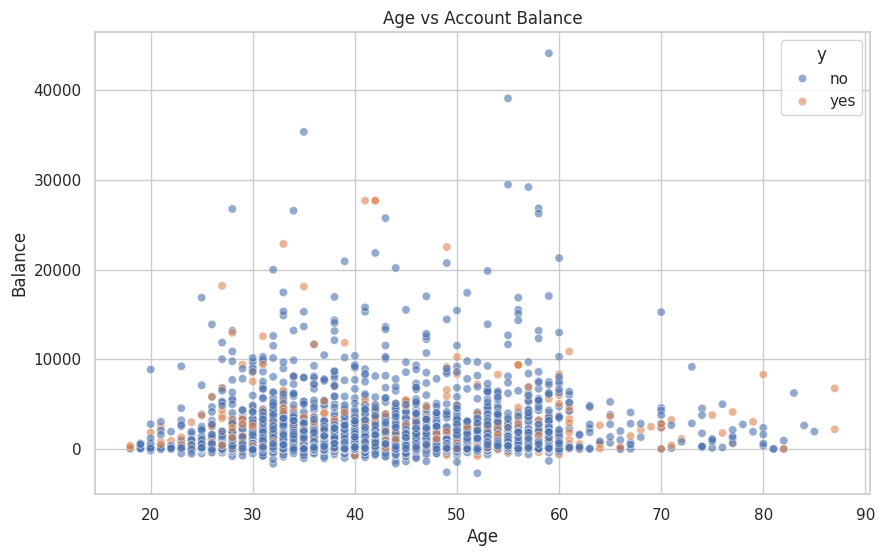

In [87]:
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="age",
    y="balance",
    hue="y",
    alpha=0.6
)

plt.title("Age vs Account Balance")
plt.xlabel("Age")
plt.ylabel("Balance")

plt.show()

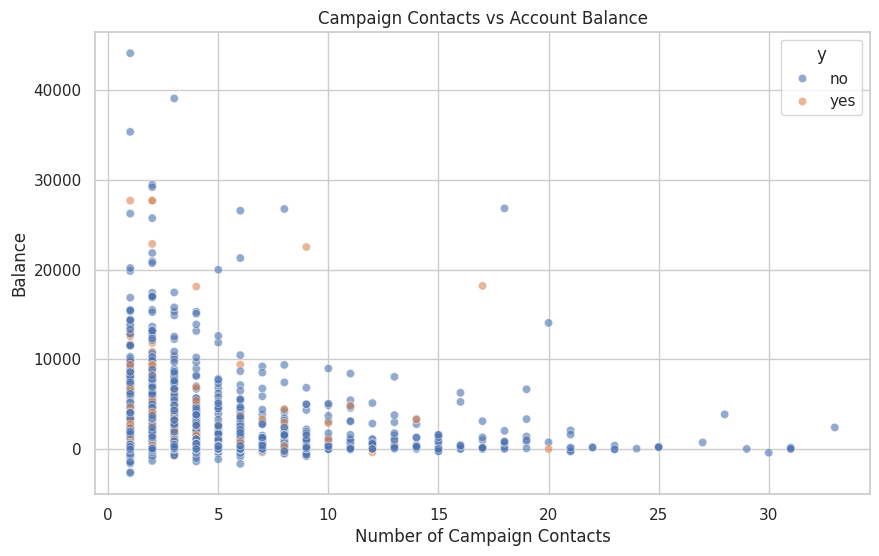

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="campaign",
    y="balance",
    hue="y",
    alpha=0.6
)

plt.title(
    "Campaign Contacts vs Account Balance"
)

plt.xlabel("Number of Campaign Contacts")
plt.ylabel("Balance")

plt.show()

In [89]:
numeric_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

correlation = df[numeric_columns].corr()

correlation

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


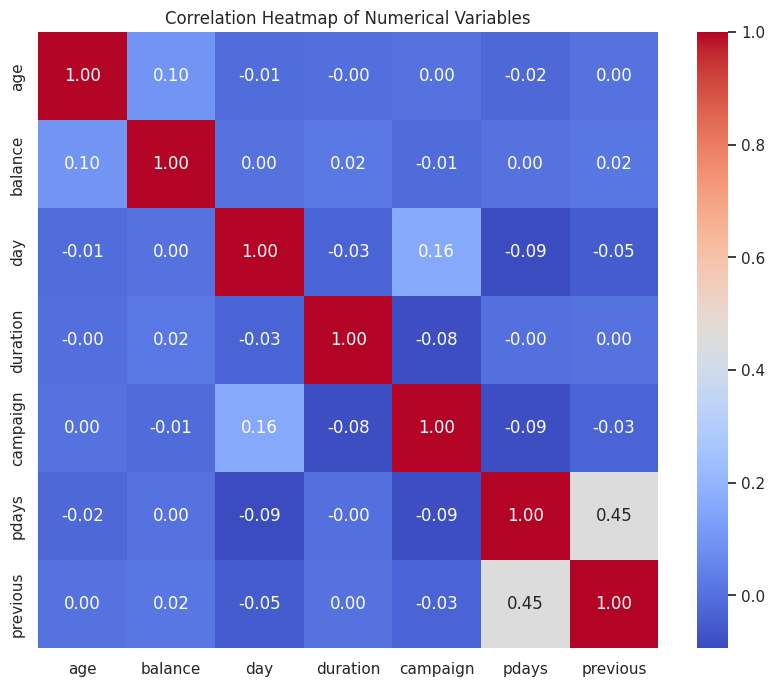

In [90]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap of Numerical Variables"
)

plt.show()

In [91]:
Q1_balance = df["balance"].quantile(0.25)
Q3_balance = df["balance"].quantile(0.75)

IQR_balance = Q3_balance - Q1_balance

lower_balance = (
    Q1_balance - 1.5 * IQR_balance
)

upper_balance = (
    Q3_balance + 1.5 * IQR_balance
)

balance_outliers = df[
    (df["balance"] < lower_balance) |
    (df["balance"] > upper_balance)
]

print(
    "Balance outliers:",
    len(balance_outliers)
)

Balance outliers: 4729


In [92]:
Q1_campaign = df["campaign"].quantile(0.25)
Q3_campaign = df["campaign"].quantile(0.75)

IQR_campaign = (
    Q3_campaign - Q1_campaign
)

lower_campaign = (
    Q1_campaign - 1.5 * IQR_campaign
)

upper_campaign = (
    Q3_campaign + 1.5 * IQR_campaign
)

campaign_outliers = df[
    (df["campaign"] < lower_campaign) |
    (df["campaign"] > upper_campaign)
]

print(
    "Campaign contact outliers:",
    len(campaign_outliers)
)

Campaign contact outliers: 3064


In [93]:
housing_subscription = pd.crosstab(
    df["housing"],
    df["y"],
    normalize="index"
) * 100

housing_yes_rate = (
    housing_subscription["yes"]
)

housing_yes_rate

,yes
housing,
no,16.702355
yes,7.699960


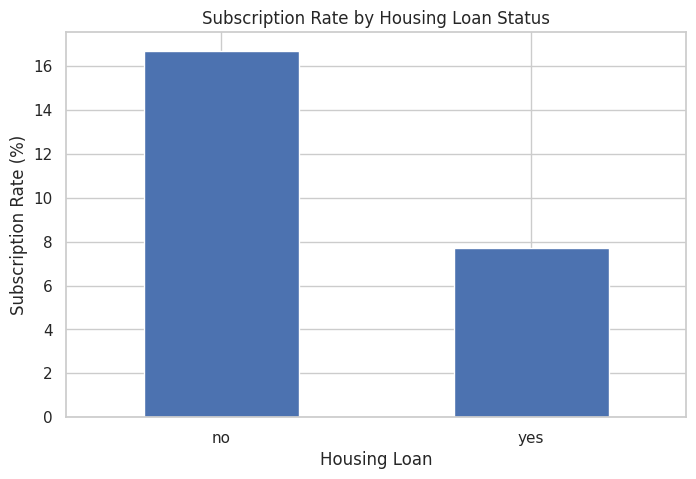

In [94]:
plt.figure(figsize=(8, 5))

housing_yes_rate.plot(
    kind="bar"
)

plt.title(
    "Subscription Rate by Housing Loan Status"
)

plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [95]:
loan_subscription = pd.crosstab(
    df["loan"],
    df["y"],
    normalize="index"
) * 100

loan_yes_rate = (
    loan_subscription["yes"]
)

loan_yes_rate

,yes
loan,
no,12.655727
yes,6.681391


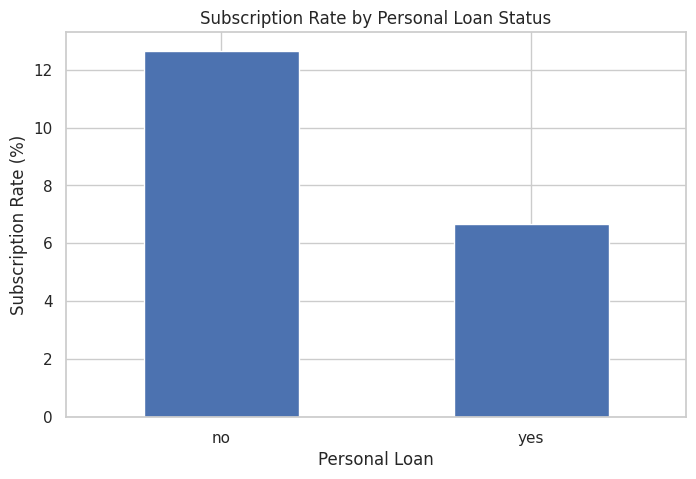

In [96]:
plt.figure(figsize=(8, 5))

loan_yes_rate.plot(
    kind="bar"
)

plt.title(
    "Subscription Rate by Personal Loan Status"
)

plt.xlabel("Personal Loan")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [97]:
summary = {
    "Total Customers": len(df),
    "Subscribed Customers": (
        df["y"].eq("yes").sum()
    ),
    "Subscription Rate (%)": (
        df["y"].eq("yes").mean() * 100
    ),
    "Average Age": df["age"].mean(),
    "Average Balance": df["balance"].mean(),
    "Average Campaign Contacts": (
        df["campaign"].mean()
    ),
    "Unique Job Types": df["job"].nunique(),
    "Unique Education Levels": (
        df["education"].nunique()
    )
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Customers,45211.000000
1,Subscribed Customers,5289.000000
2,Subscription Rate (%),11.698480
3,Average Age,40.936210
4,Average Balance,1362.272058
5,Average Campaign Contacts,2.763841
6,Unique Job Types,12.000000
7,Unique Education Levels,4.000000
